# Research Analyst Agent

Pipeline: **planner** → subtopics → fan out to **researcher** (one call per subtopic, in parallel) → **combiner** → **fact_checker** → if contradictions found, loop back to **researcher** (with the contradiction points so it can correct itself) → once clean, **writer** produces the final report.


In [36]:
import os
import json
from dotenv import load_dotenv
from groq import Groq
from pydantic import BaseModel
from typing import Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Send

In [37]:
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    groq_api_key=GROQ_API_KEY
)

In [38]:
def merge_or_reset(left: list, right: list) -> list:
    """Reducer for `data`: normally appends, but a ['__RESET__'] update clears it."""
    if right == ["__RESET__"]:
        return []
    return left + right


class State(BaseModel):
    topic: str
    subtopics: list = []
    data: Annotated[list, merge_or_reset] = []
    combined_data: str = ""
    next_agent: Literal['END', 'planner', 'researcher', 'combiner', 'fact_checker', 'writer'] = "planner"
    final_report: str = ""
    complete: bool = False
    contradiction_points: str = ""
    fact_status: bool = True


class ResearcherInput(BaseModel):
    """Slim schema for the fanned-out researcher branches (one per subtopic)."""
    subtopic: str
    contradiction_points: str = ""

In [39]:
import os

from langchain_core.tools import tool
from tavily import TavilyClient
load_dotenv()

api_key = os.getenv("TAVILY_API_KEY")

if not api_key:
    raise ValueError("TAVILY_API_KEY environment variable not found")

client = TavilyClient(api_key=api_key)

@tool
def web_search(query: str) -> str:
    """
    Search the web for up-to-date information.
    """
    result = client.search(
        query=query,
        max_results=5
    )

    return str(result)

tools = [web_search]

llm_with_tools = llm.bind_tools(tools)

In [40]:
def orchestrator(state):
    return {
        "topic": state.topic,
        "next_agent": "planner"
    }

In [41]:
#AGENT:1 RESEARCH PLANNER
def planner(state):
    task = state.topic

    plan_prompt = f"""
    You are a research planner. Your task is to divide the given topic into a list of subtopics that can be researched independently.
    The topic is: {task}.

    Return STRICTLY a JSON array of subtopic strings and nothing else - no markdown, no commentary.
    Example: ["Subtopic 1", "Subtopic 2"]
    - At max give only two subtopics
    """
    plan_response = llm.invoke([HumanMessage(content=plan_prompt)])
    content = plan_response.content.strip()

    # Strip markdown code fences if the model wraps the JSON anyway
    if "```" in content:
        content = content.split("```")[1]
        if content.startswith("json"):
            content = content[len("json"):]
        content = content.strip()

    try:
        subtopics = json.loads(content)
    except json.JSONDecodeError:
        # Fallback: treat the whole topic as a single subtopic rather than failing the run
        subtopics = [task]

    print("Subtopics:", subtopics)

    return {
        "subtopics": subtopics,
        "next_agent": "researcher"
    }

In [42]:
#AGENT:2 WEB RESEARCHER
from langchain.agents import create_agent

research_agent = create_agent(
    model=llm,
    tools=[web_search]
)

def researcher(payload):
    """
    Runs once per subtopic (fanned out via Send from the planner / retry step).
    `payload` matches ResearcherInput: {"subtopic": ..., "contradiction_points": ...}
    """
    subtopic = payload["subtopic"]
    contradiction_points = payload.get("contradiction_points", "")

    correction_note = ""
    if contradiction_points:
        correction_note = f"""
    A previous fact-check pass found the following contradictions in earlier research on this topic:
    {contradiction_points}

    Please specifically re-check and correct these points using fresh web search results.
    """

    prompt = f"""
    You are a web researcher.

    Research: {subtopic}
    {correction_note}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies

    Use the available web search tool whenever needed and answer in maximum 100 words

    Return ONLY valid JSON.
    """

    result = research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        }
    )

    return {"data": [result["messages"][-1].content]}

In [43]:
def fan_out_to_researchers(state):
    """
    Conditional-edge function: turns the subtopic list into one Send per subtopic,
    so `researcher` runs in parallel for each one. Also forwards along any
    contradiction points found by the fact checker (empty on the first pass).
    """
    return [
        Send("researcher", {"subtopic": s, "contradiction_points": state.contradiction_points})
        for s in state.subtopics
    ]

In [44]:
#COMBINER - fan-in: waits for every researcher branch, then merges the results
def combiner(state):
    combined = "\n\n---\n\n".join(state.data)
    return {
        "combined_data": combined,
        "next_agent": "fact_checker"
    }

In [45]:
#AGENT:3 FACT CHECKER
def fact_checker(state):
    task = state.combined_data

    fact_prompt = f"""
    You are a fact checker. Your task is to fact check every data point and spot contradictions in : {task}.

    - If no contradictions are found, respond with EXACTLY: NO_CONTRADICTIONS
    - If contradictions are found, describe them clearly in plain text (which points conflict, and why).
    """
    fact_response = llm.invoke([HumanMessage(content=fact_prompt)])
    content = fact_response.content.strip()

    if "NO_CONTRADICTIONS" in content:
        return {
            "fact_status": True,
            "contradiction_points": "",
            "next_agent": "writer"
        }

    return {
        "fact_status": False,
        "contradiction_points": content,
        "next_agent": "researcher"
    }

In [46]:
def reset_for_retry(state):
    """Clears `data` before re-running the researchers, so the retry round doesn't
    just pile new research on top of the contradiction-containing old research."""
    return {"data": ["__RESET__"]}


def router(state):
    return "writer" if state.fact_status else "reset_for_retry"

In [47]:
#AGENT:4 WRITER
def writer(state):
    data = state.combined_data
    topic = state.topic
    subtopics = state.subtopics

    writer_prompt = f"""
    You are a writer. Your task is to create a research document on the data provided: {data} based on the topic : {topic}.
    - The data is divided based on the subtopics: {subtopics}.
    - Output a properly formatted string along with the topic on top with proper sizes of the headings and subheadings.
    Be concise but thorough.
    """
    writer_response = llm.invoke([HumanMessage(content=writer_prompt)])
    return {
        "final_report": writer_response.content,
        "next_agent": "END"
    }

In [ ]:
workflow = StateGraph(State)

# Nodes
workflow.add_node("orchestrator", orchestrator)
workflow.add_node("planner", planner)
workflow.add_node("researcher", researcher, input_schema=ResearcherInput)
workflow.add_node("combiner", combiner)
workflow.add_node("fact_checker", fact_checker)
workflow.add_node("reset_for_retry", reset_for_retry)
workflow.add_node("writer", writer)

workflow.set_entry_point("orchestrator")
workflow.add_edge("orchestrator", "planner")

# planner fans out to one researcher call per subtopic
workflow.add_conditional_edges("planner", fan_out_to_researchers, ["researcher"])

# every researcher branch feeds into the single combiner (fan-in)
workflow.add_edge("researcher", "combiner")
workflow.add_edge("combiner", "fact_checker")

# fact_checker either goes to the writer, or clears + retries research
workflow.add_conditional_edges(
    "fact_checker",
    router,
    {
        "writer": "writer",
        "reset_for_retry": "reset_for_retry",
    },
)

# retry: fan out to the researchers again (now carrying contradiction_points)
workflow.add_conditional_edges("reset_for_retry", fan_out_to_researchers, ["researcher"])

workflow.add_edge("writer", END)

graph = workflow.compile()

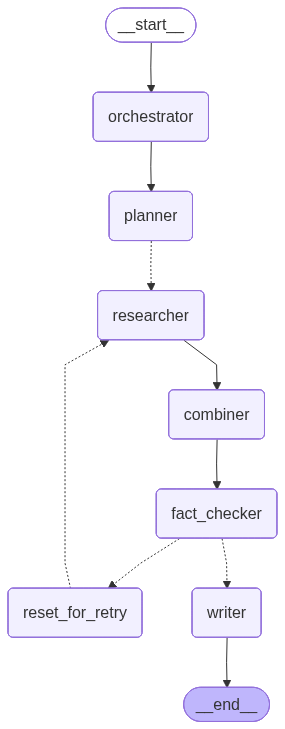

In [49]:
graph

In [51]:
response = graph.invoke({
    "topic": "AI in Defense",
    "subtopics": [],
    "data": [],
    "combined_data": "",
    "next_agent": "planner",
    "final_report": "",
    "complete": False,
    "contradiction_points": "",
    "fact_status": True
})

Subtopics: ['Autonomous Weapon Systems', 'AI-Driven Cybersecurity in Defense']


In [52]:
print(response["final_report"])
print(response["next_agent"])

# AI in Defense  

## Autonomous Weapon Systems (AWS)  
### Key Facts & Background  
- AWS are lethal platforms capable of selecting and engaging targets with minimal human oversight, integrating AI, sensors, and weaponry.  
- They span unmanned ground vehicles, lethal drones, and cyber‑attack bots.  

### Current Trends & Developments  
- Rapid AI progress, heightened state investment, and commercial‑military collaborations expand AWS capabilities.  
- Nations are adopting “human‑in‑the‑loop” and “human‑on‑the‑loop” frameworks to balance autonomy with accountability.  

### Important Statistics & Data Points  
- Global AWS market: **USD 14.2 billion (2024)**, projected to reach **USD 33.5 billion by 2030**.  
- Over 30 countries field operational AWS; the U.S., China, and Israel lead deployments.  

### Notable Examples & Case Studies  
- **Israel** – Harpy loitering munition.  
- **U.S.** – MQ‑9 Reaper drone.  
- **China** – Pterosaur UAV.  
- **Russia** – S‑400‑based autonomous miss